# Implementing Discrete Namouni Mapping Using Individual Orbital Elements

S. Trongdee
07/17/2026

In order to determine the stability of a planetary system, one could examine two planets with adjacent orbits and assume that they are closely separated. This is called the Hill's limit, and the major gravitational effects to the system only occur at conjunctions, which allows us to simplify the n-body problem and update orbital elements in discrete steps. Such work has been done in Duncan, et al. (1989) (or DQT) and Namouni et al. (1996).

The two planets in this problem can orbit in a certain integer period ratio, which is called the two-body mean motion resonance. The strength of each resonance ratio depends on the system's configuration and the interaction can cause the period ratio to oscillate and lead to either stable or unstable regime. While this can explain much of the dynamics, the two-planet framework is not yet realistic for capturing what really happens in the existing system. Adding one more adjacent body can help in this situation in the simplest way possible. However, this can interact with either existing body, which we assume to be the closest one for simplicity, and form another resonance with it. The resonance here can overlap with the other existing resonance, causing the secondary resonance which we call the three-body resonance.

Since the existing models regarding this are mathematically rigorous, we are interested in developing a simpler model that help us understand the dynamics of this three-body resonance. Our first attempt to this was not yet successful because some parameters, such as eccentricity, should not be assumed constant. Thus, we need to reconsider the model that updates the orbital elements from the aforementioned groups and turn it into the smooth model.

We already have the code for the first-order Namouni mapping (equations C.1.34-41 in Lizzy's thesis) in both original and ODE versions. However, to keep track of changes in the three-planet system, it would be more convenient if the mapping could just take the elements from each planet and output them at the next conjunction right away without finding relative values.

Because the three-body resonances can come from the overlapping of two two-body resonances, one from the inner pair (inner massive planet and middle massless test particle) and another from the outer pair (middle massless test particle and outer massive planet), we should be able to simulate both pairs and see if the Namouni mapping works for the outer pair! (Lizzy's thesis only considered the inner pair.)

In this notebook, we have the Namouni mapping equations implemented in three versions: original discrete mapping that takes in the relative eccentricity and semimajor axis, the smoothed-out version that is written as a system of coupled differential equations, and the new version where we can input the individual orbital elements involved in the evolution during the conjunction and output the individual orbital elements. In addition, we also implement the DQT mapping and compare the result with the Namouni mapping because both should be equivalent. We also implement the second-order Namouni mapping in the same manners to tackle the lower eccentricity limit. This notebook will include the interface where you can select the mapping order.

In [1]:
# First, import some vital stuff

import matplotlib.pyplot as plt
import rebound
import numpy as np
import pandas as pd
import scipy
import math
import random
from scipy.optimize import minimize
from scipy.integrate import solve_ivp, odeint
from scipy.signal import find_peaks

The setup code below also take the index of the massive planet to indicate whether it is an inner or outer pair. It is written so that it can line up the first conjunction at t=0 at our desired angle and take some steps back so that this first conjunction is detectable. Note that the orbital shape might have changed as the planets move and interact, and the position of the conjunction might have been deviated. We need to take that change into account.

The code guesses the value of $\lambda$, the mean longitude, at conjunction, and uses variational equations (derivatives in REBOUND) to find the correction according to the first-order expansion:
$$
\begin{align*}
\lambda_{\text{target}} &= \lambda_0 + \frac{d \lambda_{\text{target}}}{dx}(x-x_0)
\end{align*}
$$
The code iterates to some number of times until we get the value close to our desired value.

(Update: 06/17/2026) Jackson C. has figured out a more proper way to use variational equations, which is to create variational particles with respect to the $x$ position instead.

In [2]:
def setup_tri(j, k, mutot, etilde, pomega2, lambda_target, ind, iterations = 20):
    ecross = 2*k/(3*j)
    n1 = 2*np.pi
    n2 = n1*(j-k)/j
    tconj = 2*np.pi/(n1-n2) # estimate for time between conjunctions
    t0 = -0.8*tconj

    lambda10 = lambda_target+n1*t0 # this should be exact since 
    lambda20 = lambda_target+n2*t0

    setupSim=rebound.Simulation()
    setupSim.add(m=1)
    
    if ind == 1:
        setupSim.add(P=j/(j-k), e=etilde*ecross, pomega=pomega2, l=lambda_target)
        x_target = setupSim.particles[1].x
    else:
        setupSim.add(P=1, e=etilde*ecross, pomega=pomega2, l=lambda_target)
        x_target = setupSim.particles[1].x

    if ind == 1: #inner pair
        lambda_20_prev = lambda20 # initial guess
        correction = 0
        for i in range(iterations):
            lambda_20 = lambda_20_prev + correction
            sim = rebound.Simulation()
            sim.add(m=1)
            sim.add(primary=sim.particles[0], m=mutot, P=1, l=lambda10)
            sim.add(primary=sim.particles[0], P=j/(j-k), e=etilde*ecross, pomega=pomega2, l=lambda_20)
            var_l = sim.add_variation()
            var_l.vary(2, 'l') # how does everything depend on the initial l of particles[2]
            sim.t = t0
            ps = sim.particles
            
            sim.integrate(0)
            correction = (x_target - ps[2].x)/var_l.particles[2].x
            lambda_20_prev = lambda_20
            #print('***',i,'***')
            #print(lambda_20_prev, ps[2].l, lambda_target-ps[2].l, correction)
        
       
        lambda_20 = lambda_20_prev + correction
        sim = rebound.Simulation()
        sim.add(m=1)
        sim.add(primary=sim.particles[0], m=mutot, P=1, l=lambda10)
        sim.add(primary=sim.particles[0], P=j/(j-k), e=etilde*ecross, pomega=pomega2, l=lambda_20)
    else: #outer pair
        lambda_10_prev = lambda10 # initial guess
        correction = 0
        for i in range(iterations):
            lambda_10 = lambda_10_prev + correction
            sim = rebound.Simulation()
            sim.add(m=1)
            sim.add(primary=sim.particles[0],P=1,e=etilde*ecross, pomega=pomega2, l=lambda_10)
            sim.add(primary=sim.particles[0],m=mutot, P=j/(j-k), l=lambda20)
            var_l = sim.add_variation()
            var_l.vary(1, 'l') # how does everything depend on the initial l of particles[2]
            sim.t = t0
            ps = sim.particles
        
            sim.integrate(0)
            correction = (x_target - ps[1].x)/var_l.particles[1].x
            lambda_10_prev = lambda_10
            #print('***',i,'***')
            #print(lambda_10_prev, ps[2].l, lambda_target-ps[2].l, correction)
        
       
        lambda_10 = lambda_10_prev + correction
        sim = rebound.Simulation()
        sim.add(m=1)
        sim.add(primary=sim.particles[0], P=1,e=etilde*ecross, pomega=pomega2, l=lambda_10)
        sim.add(primary=sim.particles[0], m=mutot, P=j/(j-k), l=lambda20)
    sim.t = t0
    return sim

In [3]:
def unwrap_l(ps):
    ''' given a sim.particles object ps, returns relative lambda (l) value of the planets
        removing the 2*pi discontinuities that result when one planet has crossed l=0 but
        the other has not
    '''
    if ps[2].l - ps[1].l > np.pi:
        return ps[2].l - ps[1].l - 2*np.pi
    elif ps[2].l - ps[1].l < -np.pi:
        return ps[2].l - ps[1].l + 2*np.pi
    else:
        return ps[2].l - ps[1].l

In [4]:
def new_run(sim, Nconj, Nout, ind):
    '''
    This function runs the Nbody simulation until we get Nconj conjunctions 
    and save the orbital parameters and conjunction times.
    '''
    # this function now saves individual semimajor axis length and other individual variables (will keep adding)
    ps = sim.particles
    n1 = ps[1].n
    n2 = ps[2].n
    tmin = sim.t
    #print(tmin)
    tconj = 2*np.pi/(n1-n2)
    tmax = Nconj*tconj + 0.8*tmin

    a12_arr, l12_arr, l2, theta_arr, pomega_arr, e12_arr, diffn_arr = np.zeros(Nout), np.zeros(Nout), np.zeros(Nout), np.zeros(Nout), np.zeros(Nout), np.zeros(Nout), np.zeros(Nout)
    e1, e2, pomega1, pomega2, a1_arr, a2_arr = np.zeros(Nout), np.zeros(Nout), np.zeros(Nout), np.zeros(Nout), np.zeros(Nout), np.zeros(Nout)
    n1_arr, n2_arr = np.zeros(Nout), np.zeros(Nout)
    l1 = np.zeros(Nout)
    times = np.linspace(tmin, tmax, Nout)
    #print(times)
    for i, time in enumerate(times):
        if ind==1:
            a12_arr[i] = (ps[2].a - ps[1].a)/ps[1].a # relative semimajor axis (a-a_p)/a_p
        else:
            a12_arr[i] = (ps[1].a - ps[2].a)/ps[2].a # now the second index is the planet
        a1_arr[i] = ps[1].a
        a2_arr[i] = ps[2].a
        l12_arr[i] = unwrap_l(ps) 
        e1_vec_temp= ps[1].e * np.exp(1j * ps[1].pomega)
        e2_vec_temp= ps[2].e * np.exp(1j * ps[2].pomega)
        if ind==1:
            pomega12_temp = np.angle(e2_vec_temp-e1_vec_temp)
            e12_temp = np.abs(e2_vec_temp-e1_vec_temp)
        else:
            pomega12_temp = np.angle(e1_vec_temp-e2_vec_temp)
            e12_temp = np.abs(e1_vec_temp-e2_vec_temp)
        theta_arr[i] = ps[2].l - pomega12_temp

        l1[i] = ps[1].l
        l2[i] = ps[2].l
        pomega_arr[i] = pomega12_temp
        e12_arr[i] = e12_temp

        n1_arr[i] = ps[1].n
        n2_arr[i] = ps[2].n
        e1[i] = ps[1].e
        e2[i] = ps[2].e
        pomega1[i] = ps[1].pomega
        pomega2[i] = ps[2].pomega
        diffn_arr[i] = ps[1].n - ps[2].n
        sim.integrate(time)

    l1 = np.unwrap(l1)
    l2 = np.unwrap(l2)
    
    # conjunctions occur at minima pf dl = maxima of -dl
    conj_idx, _ = find_peaks(-np.abs(l12_arr))
    if len(conj_idx) != Nconj:
        print("WARNING: wrong number of conjunction events found \n {} conjunctions found, {} conjunctions input".format(len(conj_idx), Nconj))
        #raise Exception('''wrong number of conjunction events found \n {} conjunctions found, 
        #                {} conjunctions input'''.format(len(conj_idx), Nconj))
    #pts_btwn_conj = (.5*np.diff(conj_idx)).astype(np.int64)

    btwn_conj_idx, properties = find_peaks(np.abs(l12_arr))
    #btwn_conj_idx[1:] = conj_idx[:-1] + pts_btwn_conj

    return [times, a12_arr, l12_arr, theta_arr, l1, l2, pomega_arr, e12_arr, e1, e2, pomega1, pomega2, diffn_arr, conj_idx, btwn_conj_idx, a1_arr, a2_arr, n1_arr, n2_arr]


In [5]:
def wrap_angles(angles):
    return (angles + np.pi) % (2 * np.pi) - np.pi

Here we have the homemade integrator that solves the differential equations from the Namouni mapping.

In [6]:
#Integrator for our setup
def integrate_3br_2(func, y0, t, dt, args=()):
    """
    General symplectic integrator (odeint-compatible API).

    Parameters
    ----------
    func : callable
        Function f(y, t, *args) returning dy/dt as 1D array of len(y0).
        First half of y are "positions" q, second half "momenta" p.
    y0 : array_like
        Initial state vector [q1, ..., qN, p1, ..., pN].
        Must have even length.
    t : array_like
        Times at which to output the solution.
    args : tuple, optional
        Additional parameters for func.
    dt : float, optional
        Internal integration timestep. Defaults to min(diff(t)) / 10.

    Returns
    -------
    y_out : ndarray
        Array of shape (len(t), len(y0)) containing y(t) at each output time.
    """
    t = np.asarray(t, dtype=float)
    t_max = t[-1]
    numout = len(t)
    numpara = len(y0)
    y_out = np.zeros((numout, numpara)) #array to store the solution
    next_index = 0
    t_curr = 0
    for step in range(int(t_max/dt)+2):
        #update at conjunction only - same logic as update at any desired time!
        #the >= sign in the second condition ensures that if the time after increment is slightly off we still have something
        #otherwise we won't get the solution at that point
        while next_index < numout and t_curr >= t[next_index]:
            y_out[next_index] = y0
            next_index += 1
            
        #step update using the derivative calculated at the latest conjunction
        dydt = np.asarray(func(y_out[next_index-1], t_curr, *args), dtype = float)
        y0 += dydt*dt
        t_curr += dt

    return y_out

Now we define a function that evaluates the derivative. The parameters we can change into continuous functions are $h$, $k$, $K$, and $\lambda$. See that the derivatives can be approximated by the (small) differences between two neighboring values of indices $n+1$ and $n$ over the time interval between two closest conjunctions. That is,
$$
\begin{align}
\dot{h}\approx \frac{\delta h}{\Delta t_{\text{conj}}} &= -\frac{2W_{1}^{1,0}}{a_r^2\Delta t_{\text{conj}}}\sin\lambda \\
\dot{k}\approx \frac{\delta k}{\Delta t_{\text{conj}}} &= \frac{2W_{1}^{1,0}}{a_r^2\Delta t_{\text{conj}}}\cos\lambda \\
\dot{K}\approx \frac{\delta K}{\Delta t_{\text{conj}}} &= \frac{\delta I}{\Delta t_{\text{conj}}} \\
&=\frac{h\delta h}{\Delta t_{\text{conj}}}+\frac{k\delta k}{\Delta t_{\text{conj}}} \\
&=\frac{2W_{1}^{1,0}}{a_r^2\Delta t_{\text{conj}}}(-h\sin\lambda+k\cos\lambda) \\
\dot{\lambda}\approx \frac{\delta \lambda}{\Delta t_{\text{conj}}} &= \frac{4\pi}{\Delta t_{\text{conj}}\epsilon\sqrt{24 K}}
\end{align}
$$
These equations resemble those in Namouni mapping, but we have thrown the discrete indices away, and they are divided by $\Delta t_{\text{conj}}$! Here, we treat $\Delta t_{\text{conj}}$ as a constant, as it changes slightly in the simulation, and use its average value.

In [7]:
#Change Namouni mapping into coupled differential equations
def derivatives(z, t, W1, ar0, epsilon, dtconj):
    #print(z)
    #z is the current state where we want to know the derivative
    h, k, K, lamb = z
    c1 = 2*W1/ar0**2/dtconj
    c2 = 4*np.pi/(np.sqrt(24)*epsilon)/dtconj
    return [-c1*np.sin(lamb), c1*np.cos(lamb), -h*c1*np.sin(lamb)+k*c1*np.cos(lamb), c2/np.sqrt(K)]

In [8]:
def derivatives_exact(z, t, W1, ar0, epsilon, dtconj):
    #print(z)
    #z is the current state where we want to know the derivative
    h, k, K, lamb = z
    c1 = 2*W1/ar0**2/dtconj
    c2 = 2*np.pi/dtconj
    return [-c1*np.sin(lamb), c1*np.cos(lamb), -h*c1*np.sin(lamb)+k*c1*np.cos(lamb), c2*np.abs(1/((1+np.sqrt(8*K/3)*epsilon)**(-3/2)-1))]

Now we're ready to create a setup. First, we specify the parameters we want for our system and how we want it to look like. We can also choose the order of the mapping and the pair of planets we want to simulate.

In [9]:
#Parameters and initial conditions
#mean motion resonance ratio
j = 10
k = 1
mutot = 1e-7 #mass of the planet
etilde=0.0 #eccentricity
pomega2=0
lambda_target= 0 # where we want conjunction to happen/ analogous to lambda0 in lizzy's
Nconj = 1000 #number of conjunctions
Nout = Nconj*100
ind = 3# 1 for inner pair, 3 for outer pair
order = 2 # mapping order: 1 for first, 2 for second
ecross = 2*k/(3*j)
print(ecross)
print(etilde*ecross)

0.06666666666666667
0.0


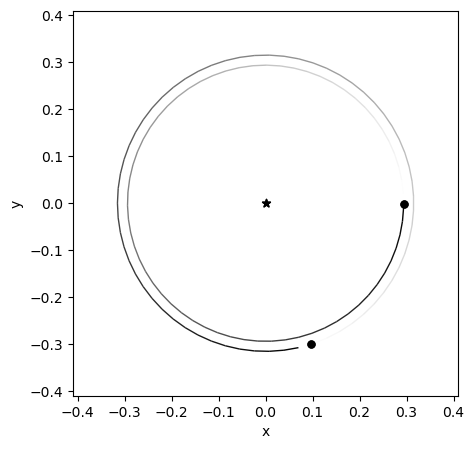

In [10]:
#Setup the nbody simulation to extract initial parameters and save others to compare
#sim = setup_dup(j,k,mutot,etilde,pomega2,lambda_target)
sim = setup_tri(j,k,mutot,etilde,pomega2,lambda_target,ind)
ps = sim.particles
#sim.integrate(0)
rebound.OrbitPlot(sim)

Now, we are ready to integrate using REBOUND for some amount of conjunctions! Here, we also save the parameters between the conjunctions to use in and compare with the Namouni mapping. We are not using some parameters during exactly the conjunction because the conjunction can cause a spike in the value before it returns to the new one after the interaction ends, which is why we find the values between conjunctions more representative. The smooth model also removes those spikes at conjunctions.

In [11]:
#parameters from simulation
times, a12, l12, theta2, l1, l2, pomega12, e12, e1, e2, pomega1, pomega2, diffn_arr, conj_idx, btwn_conj_idx, a1_arr, a2_arr, n1_arr, n2_arr = new_run(sim, Nconj, Nout, ind)
tconjs = times[conj_idx]  
tbetweens = times[btwn_conj_idx]  
an = a12[btwn_conj_idx]              # Relative semimajor axis
e12n = e12[btwn_conj_idx]            # Relative eccentricity
#individual values
a1_conj = a1_arr[btwn_conj_idx] 
a2_conj = a2_arr[btwn_conj_idx]
e1_conj = e1[btwn_conj_idx]
e2_conj = e2[btwn_conj_idx]
pomega1_conj = pomega1[btwn_conj_idx]
pomega2_conj = pomega2[btwn_conj_idx]
pomegan = pomega12[btwn_conj_idx]    # Relative periapse
if ind == 1:
    lambdan = l2[conj_idx]               # Lambda at conjunctions
else:
    lambdan = l1[conj_idx]  
diffnconj = diffn_arr[conj_idx]

if Nconj != len(conj_idx):
    Nconj = len(conj_idx)
    print("wrong number of conjunctions fixed")

The mapping only cares about the values at conjunction, so we need to take the parameters from the first conjunction in Nbody and set them as the initial values in the mapping. This is why we want the first conjunction to happen at t=0!

In [12]:
#extract values for Namouni mapping and use in the equations
epsilon = (mutot/3)**(1/3)                      # Small mass parameter
print(epsilon)
eps0 = an[0]                                    # relative semimajor axis (scaled) - curly epsilon in DQT
ar0 = an[0] / epsilon                           # Initial scaled semimajor axis in Hill's unit
K0 = 3/8*ar0**2
I0 = (e12n[0]/epsilon)**2 / 2                   #Initial action
phi0 = pomegan[0] 

lambda0 = lambdan[0]                            # Initial conj angle

#eccentricity vector components
h0 = np.sqrt(2*I0)*np.cos(phi0)
k0 = np.sqrt(2*I0)*np.sin(phi0)

fe0 = np.abs(1/((1+an[0])**(-3/2)-1))
beta0 = lambda0 - np.pi*fe0 + np.pi #opposition longitude, theta in dqt but we rename it because theta is already used
print(eps0)
print(lambda_target, np.mod(lambda0, 2*np.pi), h0, k0, I0,K0)
print(phi0, np.arctan2(k0,h0))
print(ar0, ar0*epsilon)
print(fe0, beta0)

0.0032182979486854338
-0.06782878429537306
0 0.0014092106551686356 -5.213084953907642e-05 2.0835817384940094e-05 1.5758783798821979e-09 166.5738552375531
2.761359531783003 2.761359531783003
-21.07598034019157 -0.06782878429537306
9.000212014239441 31.416669684176014


We should also be able to calculate the actual times between two consecutive conjunctions from the simulation. Their average gives the $\Delta t_{\text{conj}}$ we need for the smooth model.

In [13]:
#average delta tconj for the smooth function approximation
deltatconj = np.diff(tconjs) # find all possible time intervals between two adjacent conjunctions
deltatconj_fixed = []
for deltat in deltatconj:
    # There are some outliers that are less than 11, so we have to filter out. This number is from inspection, no science involved.
    #if(deltat > 11):
    deltatconj_fixed.append(deltat)

deltatconj_fixed = np.array(deltatconj_fixed)
dtconj = np.mean(deltatconj_fixed) 
dtconj_theory = 2/3/ecross #theoretical value
print(dtconj)
print(dtconj_theory)

9.995592872845675
10.0


This is the first- and second-order Namouni mappings for one step. The second-order mapping can be useful when the eccentricity is very small because it contains the second order corrections in the eccentricity vector. In addition, we have also implemented the function for DQT (Duncan et al) mapping where the first-order Namouni mapping can be derived from so that we can check if either mapping works properly.

In [14]:
#extract eccentricity vector components
e1_vec = e1_conj[0] * np.exp(1j * pomega1_conj[0])
#e1_vecarr = [np.real(e1_vec), np.imag(e1_vec)]
e2_vec = e2_conj[0] * np.exp(1j * pomega2_conj[0])
#e2_vecarr = [np.real(e2_vec), np.imag(e2_vec)]
if ind==1:
    z0 = e2_vec - e1_vec
else:
    z0 = e1_vec - e2_vec
print(np.angle(z0), phi0)
#phi0 = np.angle(e2_vec-e1_vec)
#print((e2_vecarr[0]-e1_vecarr[0])/epsilon,(e2_vecarr[1]-e1_vecarr[1])/epsilon)
#print(np.arctan2((e2_vecarr[1]-e1_vecarr[1])/epsilon,(e2_vecarr[0]-e1_vecarr[0])/epsilon))


2.761359531783003 2.761359531783003


In [15]:
#Namouni mapping setup
W1, W2, W3, W4, W200 = 3.359350011, -2.678665722, 2.639498803, 2.8559, -1 #constants from the expansion
g = 2.23956667
#%% Namouni Mapping Functions
def calc_coeff(q, Wq, ar, theta):
    """Coefficient for power series in Namouni for the q'th order (derivatives of W wrt phi)."""
    return 2*q*2**(q/2)*Wq*np.sin(2*theta)/ar**(q+1)

def namouni_fo_step(In, Kn, phin, lambdan, arn, ind):
    """First-order Namouni mapping step."""
    hn = np.sqrt(2*In)*np.cos(phin)
    kn = np.sqrt(2*In)*np.sin(phin)
    if ind == 1:
        hprime = hn - 2*W1*np.sin(lambdan)/arn**2 # + for Namouni, - for pomega
        kprime = kn + 2*W1*np.cos(lambdan)/arn**2 # - for Namouni, + for pomega
    else: #from DQT, the sign switches for the outer pair
        hprime = hn + 2*W1*np.sin(lambdan)/arn**2 # + for Namouni, - for pomega
        kprime = kn - 2*W1*np.cos(lambdan)/arn**2 # - for Namouni, + for pomega
    phiprime = np.arctan2(kprime, hprime) # 4 quadrant arctan
    #print(hn, kn)
    # both options should give the same result:
    Inprime = 1/2*(hprime**2 + kprime**2)
    #Inprime = In + 2*W1/arn**2*np.sqrt(2*In)*np.sin(thetan) + 2*W1**2/arn**4
    #Namouni update
    hnp1 = hprime
    knp1 = kprime
    Inp1 = Inprime
    Knp1 = Kn + Inp1 - In
    phinp1 = phiprime
    lambdanp1 = lambdan + 4*np.pi/(3*epsilon*np.sqrt(8*Knp1/3))
    
    return Inp1, Knp1, phinp1, lambdanp1, hnp1, knp1

#DQT mapping - equivalent to Namouni but not scaled to Hill's unit
def dqt_step(lambdan, zn, epsn, eps0):
    #update
    znp1 = zn + 1j*g*np.exp(1j*lambdan)/eps0**2*np.sign(eps0)*mutot #ecc vector equivalent to h,k,pomega
    epsnp1 = epsn*np.sqrt(1+4*(np.abs(znp1)**2-np.abs(zn)**2)/(3*epsn**2)) #equivalent to K
    fenp1 = np.abs(1/((1+epsnp1)**(-3/2)-1)) #equivalent to change in lambda in terms of Knp1
    lambdanp1 = lambdan + 2*np.pi*fenp1 #same lambda
    phinp1 = np.angle(znp1)
    
    return lambdanp1, znp1, epsnp1

def namouni_so_step(In, Kn, phin, lambdan, arn, ind):
    """Second-order Namouni mapping step."""
    hn = np.sqrt(2*In)*np.cos(phin)
    kn = np.sqrt(2*In)*np.sin(phin)
    if ind == 1:
        hprime = hn - 2*W1*np.sin(lambdan)/arn**2 # + for Namouni, - for pomega
        kprime = kn + 2*W1*np.cos(lambdan)/arn**2 # - for Namouni, + for pomega
    else: #from DQT, the sign switches for the outer pair
        hprime = hn + 2*W1*np.sin(lambdan)/arn**2 # + for Namouni, - for pomega
        kprime = kn - 2*W1*np.cos(lambdan)/arn**2 # - for Namouni, + for pomega
    phiprime = np.arctan2(kprime, hprime) # 4 quadrant arctan
    thetaprime = phiprime - lambdan

    # A = calc_coeff(2, W2, arn, thetaprime)
    # E1 = 1/(1+A)
    # Inp1 = E1*Inprime
    hnp1 = hprime
    knp1 = kprime
    Inp1 = (0.5*(hprime**2 + kprime**2)) / (1 + 4*W2*np.sin(2*thetaprime)*2/arn**3)
    phinp1 = phiprime - (W200 + 2*W2*np.cos(2*thetaprime))*2/arn**3
    Knp1 = Kn + Inp1 - In
    lambdanp1 = lambdan + 4*np.pi/(3*epsilon*np.sqrt(8*Knp1/3))
    return Inp1, Knp1, phinp1, lambdanp1, hnp1, knp1

In [16]:
#test
print("---dqt---")
lambdanp1, znp1, epsnp1 = dqt_step(lambda0, z0, eps0, eps0)
#print("lambda: ", lambdanp1)
print("e1: ", np.abs(znp1), " pomega: ", np.angle(znp1), " semimajor: ", epsnp1)
#print("eps: ", epsnp1)

lambdanp2, znp2, epsnp2 = dqt_step(lambdanp1, znp1, epsnp1, eps0)
#print("lambda: ", lambdanp2)
print("e2: ", np.abs(znp2), " pomega: ", np.angle(znp2), " semimajor: ", epsnp2)
#print("eps: ", epsnp2)

lambdanp3, znp3, epsnp3 = dqt_step(lambdanp2, znp2, epsnp2, eps0)
#print("lambda: ", lambdanp2)
print("e3: ", np.abs(znp3), " pomega: ", np.angle(znp3), " semimajor: ", epsnp3)
#print("eps: ", epsnp2)

print("---namouni---")
Inp1, Knp1, phinp1, lambdanp1, hnp1, knp1 = namouni_fo_step(I0, K0, phi0, lambda0, ar0, ind)
#print("lambda: ", lambdanp1)
print("e1: ", np.sqrt(Inp1*2)*epsilon, " pomega: ", phinp1, " semimajor: ", np.sqrt(8*Knp1/3)*epsilon)

Inp2, Knp2, phinp2, lambdanp2, hnp2, knp2 = namouni_fo_step(Inp1, Knp1, phinp1, lambdanp1, ar0, ind)
#print("lambda: ", lambdanp2)
print("e2: ", np.sqrt(Inp2*2)*epsilon, " pomega: ", phinp2, " semimajor: ", np.sqrt(8*Knp2/3)*epsilon)

Inp3, Knp3, phinp3, lambdanp3, hnp3, knp3 = namouni_fo_step(Inp2, Knp2, phinp2, lambdanp2, ar0, ind)
#print("lambda: ", lambdanp2)
print("e3: ", np.sqrt(Inp3*2)*epsilon, " pomega: ", phinp3, " semimajor: ", np.sqrt(8*Knp3/3)*epsilon)



---dqt---
e1:  4.8611355946231636e-05  pomega:  -1.572836480449353  semimajor:  -0.0678288075208213
e2:  9.728943934498396e-05  pomega:  -1.5704546641738113  semimajor:  -0.06782887732564992
e3:  0.0001459675850379406  pomega:  -1.5692454390255732  semimajor:  -0.06782899370961677
---namouni---
e1:  4.861135603317365e-05  pomega:  -1.5728364804431838  semimajor:  0.06782880752082139
e2:  8.361889797932498e-05  pomega:  -2.1097843046059084  semimajor:  0.06782885301825117
e3:  9.497738644128118e-05  pomega:  -2.6473842409006325  semimajor:  0.06782887295650702


Note that the change in $\lambda$ in each conjunction in the Namouni map is the approximated version of that in the DQT map, which works only when the relative semimajor axis $\frac{a-a_p}{a_p}\ll 1$. So, let's implement the version of Namouni mapping where $\lambda$ is implemented in the exactly equivalent way to the DQT mapping.

In [17]:
def namouni_fo_step_noapprox(In, Kn, phin, lambdan, arn):
    """First-order Namouni mapping step."""
    hn = np.sqrt(2*In)*np.cos(phin)
    kn = np.sqrt(2*In)*np.sin(phin)
    hprime = hn - 2*W1*np.sin(lambdan)/arn**2 # + for Namouni, - for pomega
    kprime = kn + 2*W1*np.cos(lambdan)/arn**2 # - for Namouni, + for pomega
    phiprime = np.arctan2(kprime, hprime) # 4 quadrant arctan
    #print(hn, kn)
    # both options should give the same result:
    Inprime = 1/2*(hprime**2 + kprime**2)
    #Inprime = In + 2*W1/arn**2*np.sqrt(2*In)*np.sin(thetan) + 2*W1**2/arn**4
    #Namouni update
    hnp1 = hprime
    knp1 = kprime
    Inp1 = Inprime
    Knp1 = Kn + Inp1 - In
    phinp1 = phiprime
    #lambdanp1 = lambdan + 4*np.pi/(3*epsilon*np.sqrt(8*Knp1/3))
    
    
    lambdanp1 = lambdan + 2*np.pi*np.abs(1/((1+np.sqrt(8*Knp1/3)*epsilon)**(-3/2)-1)) #same lambda
    
    return Inp1, Knp1, phinp1, lambdanp1, hnp1, knp1



Here is our new version of Namouni mapping that takes in the individual orbital parameters for both first and second orders.

In [18]:
def namouni_fo_step_abs(e1_vec_n, e2_vec_n, a1_conj_n, a2_conj_n, lambdan_n, ind):
    #hard calculate the relative values
    #print(e1_0, e2_0, pomega1_0, pomega2_0, a1_conj_0, a2_conj_0, lambdan_0)
    
    if ind==1:
        e12_vec = e2_vec_n - e1_vec_n
        ar_n = (a2_conj_n-a1_conj_n)/a1_conj_n/epsilon
        Kn = 3*ar_n**2/8
    else:
        e12_vec = e1_vec_n - e2_vec_n
        ar_n = (a1_conj_n-a2_conj_n)/a2_conj_n/epsilon
        Kn = 3*ar_n**2/8
    
    pomega12_temp = np.angle(e12_vec)
    e12_mag = np.sqrt((np.real(e12_vec))**2+(np.imag(e12_vec))**2)
    In = (e12_mag/epsilon)**2 / 2  
    hn = np.sqrt(2*In)*np.cos(pomega12_temp)
    kn = np.sqrt(2*In)*np.sin(pomega12_temp)  
    #phi0 = pomega12_temp

    #mapping calculation
    if ind == 1:
        hnp1 = hn - 2*W1*np.sin(lambdan_n)/ar_n**2 # + for Namouni, - for pomega
        knp1 = kn + 2*W1*np.cos(lambdan_n)/ar_n**2 # - for Namouni, + for pomega
    else:
        hnp1 = hn + 2*W1*np.sin(lambdan_n)/ar_n**2 # + for Namouni, - for pomega
        knp1 = kn - 2*W1*np.cos(lambdan_n)/ar_n**2 # - for Namouni, + for pomega
    #phiprime = np.arctan2(kprime, hprime) # 4 quadrant arctan
    
    # both options should give the same result:
    Inp1 = 1/2*(hnp1**2 + knp1**2)
    #Inprime = In + 2*W1/arn**2*np.sqrt(2*In)*np.sin(thetan) + 2*W1**2/arn**4
    
    #phinp1 = phiprime
    Knp1 = Kn + Inp1 - In
    lambdanp1 = lambdan_n + 4*np.pi/(3*epsilon*np.sqrt(8*Knp1/3))

    
    #e12np1_mag = np.sqrt(2*Inp1)*epsilon
    e12vec = hnp1*epsilon + 1j*knp1*epsilon
    
    if ind==1: #inner pair
        arnp1 = np.sqrt(8*Knp1/3)*epsilon*a1_conj_n
        e1np1 = e1_vec_n
        a1np1 = a1_conj_n
        e2np1 = e1_vec_n + e12vec
        a2np1 = a1_conj_n+arnp1
    else: #outer pair
        arnp1 = -np.sqrt(8*Knp1/3)*epsilon*a2_conj_n
        e1np1 = e2_vec_n + e12vec
        a1np1 = a2_conj_n + arnp1
        e2np1 = e2_vec_n
        a2np1 = a2_conj_n
    return e1np1, e2np1, a1np1, a2np1, lambdanp1
# optimize K and get the optimized a2 initial condition

In [19]:
def namouni_so_step_abs(e1_vec_n, e2_vec_n, a1_conj_n, a2_conj_n, lambdan_n, ind):
    #second order Namouni mapping that inputs and outputs individual values instead of the relative ones
    #hard calculate the relative values
    #print(e1_0, e2_0, pomega1_0, pomega2_0, a1_conj_0, a2_conj_0, lambdan_0)
    if ind==1:
        e12_vec = e2_vec_n - e1_vec_n
        ar_n = (a2_conj_n-a1_conj_n)/a1_conj_n/epsilon
        Kn = 3*ar_n**2/8
    else:
        e12_vec = e1_vec_n - e2_vec_n
        ar_n = (a1_conj_n-a2_conj_n)/a2_conj_n/epsilon
        Kn = 3*ar_n**2/8
    pomega12_temp = np.angle(e12_vec)
    e12_mag = np.sqrt((np.real(e12_vec))**2+(np.imag(e12_vec))**2)
    In = (e12_mag/epsilon)**2 / 2
    hn = np.sqrt(2*In)*np.cos(pomega12_temp)
    kn = np.sqrt(2*In)*np.sin(pomega12_temp)  
    #phi0 = pomega12_temp
    if ind == 1:
        hprime = hn - 2*W1*np.sin(lambdan_n)/ar_n**2 # + for Namouni, - for pomega
        kprime = kn + 2*W1*np.cos(lambdan_n)/ar_n**2 # - for Namouni, + for pomega
    else:
        hprime = hn + 2*W1*np.sin(lambdan_n)/ar_n**2 # + for Namouni, - for pomega
        kprime = kn - 2*W1*np.cos(lambdan_n)/ar_n**2 # - for Namouni, + for pomega
    phiprime = np.arctan2(kprime, hprime) # 4 quadrant arctan
    thetaprime = phiprime - lambdan_n

    # A = calc_coeff(2, W2, arn, thetaprime)
    # E1 = 1/(1+A)
    # Inp1 = E1*Inprime
    hnp1 = hprime
    knp1 = kprime
    Inp1 = (0.5*(hprime**2 + kprime**2)) / (1 + 4*W2*np.sin(2*thetaprime)*2/ar_n**3)
    phinp1 = phiprime - (W200 + 2*W2*np.cos(2*thetaprime))*2/ar_n**3
    Knp1 = Kn + Inp1 - In
    lambdanp1 = lambdan_n + 4*np.pi/(3*epsilon*np.sqrt(8*Knp1/3))

    
    #e12np1_mag = np.sqrt(2*Inp1)*epsilon
    e12vec = hnp1*epsilon + 1j*knp1*epsilon
    if ind==1: #inner pair
        arnp1 = np.sqrt(8*Knp1/3)*epsilon*a1_conj_n
        e1np1 = e1_vec_n
        a1np1 = a1_conj_n
        e2np1 = e1_vec_n + e12vec
        a2np1 = a1_conj_n+arnp1
    else: #outer pair
        arnp1 = -np.sqrt(8*Knp1/3)*epsilon*a2_conj_n
        e1np1 = e2_vec_n + e12vec
        a1np1 = a2_conj_n + arnp1
        e2np1 = e2_vec_n
        a2np1 = a2_conj_n
    return e1np1, e2np1, a1np1, a2np1, lambdanp1
# optimize K and get the optimized a2 initial condition

Now we implement the function to run the mapping for multiple steps. We can select order of the mapping we want to use. For the version that takes in the individual values, we have to specify which pair (inner or outer).

In [20]:
#This function runs Namouni mapping for multiple conjunctions
def runmap(I0, K0, phi0, lambda0, Nconj, order):
    try:                # minimize function later passes a 1-element list, so make it work for both scalar and list
        K0 = K0[0]
    except:
        pass
    Is, Ks, phis, lambdas, hs, ks = np.zeros(Nconj+1), np.zeros(Nconj+1), np.zeros(Nconj+1), np.zeros(Nconj+1), np.zeros(Nconj+1), np.zeros(Nconj+1)
    Is[0] = I0
    Ks[0] = K0
    phis[0] = phi0
    lambdas[0] = lambda0
    ar0 = np.sqrt(8*K0/3)

    for i in range(Nconj):
        if order==1:
            Is[i+1], Ks[i+1], phis[i+1], lambdas[i+1], hs[i+1], ks[i+1] = namouni_fo_step(Is[i], Ks[i], phis[i], lambdas[i], ar0, ind)
        else:
            Is[i+1], Ks[i+1], phis[i+1], lambdas[i+1], hs[i+1], ks[i+1] = namouni_so_step(Is[i], Ks[i], phis[i], lambdas[i], ar0, ind)

    return Is, Ks, phis, lambdas, hs, ks

In [21]:
#This function runs Namouni mapping for multiple conjunctions
def runmap_dqt(lambda0, z0, eps0, Nconj):
    try:                # minimize function later passes a 1-element list, so make it work for both scalar and list
        eps0 = eps0[0]
    except:
        pass
    lambda_d, z_d, eps_d = np.zeros(Nconj+1), np.zeros(Nconj+1,dtype = 'complex_'), np.zeros(Nconj+1)
    lambda_d[0] = lambda0
    z_d[0] = z0
    eps_d[0] = eps0

    for i in range(Nconj):
        lambda_d[i+1], z_d[i+1], eps_d[i+1] = dqt_step(lambda_d[i], z_d[i], eps_d[i], eps0)
        
    return lambda_d, z_d, eps_d

In [22]:
#This function runs Namouni mapping for multiple conjunctions
#But for individual parameters
def runmap_abs(e1_vec_0, e2_vec_0, a1_conj_0, a2_conj_0, lambdan_0, Nconj, ind, order):
    try:                # minimize function later passes a 1-element list, so make it work for both scalar and list
        a1_conj_0 = a1_conj_0[0]
    except:
        pass
    e1_s, e2_s, a1_s, a2_s, lambda_s = np.zeros(Nconj+1,dtype = 'complex_'), np.zeros(Nconj+1,dtype = 'complex_'), np.zeros(Nconj+1), np.zeros(Nconj+1), np.zeros(Nconj+1)
    #print(e1_vecarr, e2_vecarr)
    e1_s[0] = e1_vec_0
    e2_s[0] = e2_vec_0
    #print(e1_s[0], e2_s[0])
    #print(a1_conj_0, a2_conj_0)
    a1_s[0] = a1_conj_0
    a2_s[0] = a2_conj_0
    lambda_s[0] = lambdan_0
    #ar0 = np.sqrt(8*K0/3)
    for i in range(Nconj):
        if order==1:
            e1_s[i+1], e2_s[i+1], a1_s[i+1], a2_s[i+1], lambda_s[i+1] = namouni_fo_step_abs(e1_s[i], e2_s[i], a1_s[i], a2_s[i], lambda_s[i], ind)
        else:
            e1_s[i+1], e2_s[i+1], a1_s[i+1], a2_s[i+1], lambda_s[i+1] = namouni_so_step_abs(e1_s[i], e2_s[i], a1_s[i], a2_s[i], lambda_s[i], ind)            

    return e1_s, e2_s, a1_s, a2_s, lambda_s

In [23]:
#running for N conjunctions
def runmap_noapprox(I0, K0, phi0, lambda0, Nconj, order):
    try:                # minimize function later passes a 1-element list, so make it work for both scalar and list
        K0 = K0[0]
    except:
        pass
    Isn, Ksn, phisn, lambdasn, hsn, ksn = np.zeros(Nconj+1), np.zeros(Nconj+1), np.zeros(Nconj+1), np.zeros(Nconj+1), np.zeros(Nconj+1), np.zeros(Nconj+1)
    Isn[0] = I0
    Ksn[0] = K0
    phisn[0] = phi0
    lambdasn[0] = lambda0
    ar0 = np.sqrt(8*K0/3)

    for i in range(Nconj):
        if order==1:
            Isn[i+1], Ksn[i+1], phisn[i+1], lambdasn[i+1], hsn[i+1], ksn[i+1] = namouni_fo_step_noapprox(Isn[i], Ksn[i], phisn[i], lambdasn[i], ar0)
        else:
            Isn[i+1], Ksn[i+1], phisn[i+1], lambdasn[i+1], hsn[i+1], ksn[i+1] =namouni_fo_step_noapprox(Isn[i], Ksn[i], phisn[i], lambdasn[i], ar0)

    return Isn, Ksn, phisn, lambdasn, hsn, ksn

In [24]:
#Then save into arrays to compare with the simulation and the equation
Is, Ks, phis, lambdas, hs, ks = runmap(I0, K0, phi0, lambda0, Nconj, order)

#not optimized value - save to compare with the optimized one
Is0, Ks0, phis0, lambdas0, hs0, ks0 = Is, Ks, phis, lambdas, hs, ks
# print("lambda: ",lambdas)
# print("pomega: ",phis)
# print("ecc: ",np.sqrt(2*Is)*epsilon)
# print("a12: ", np.sqrt(8*Ks/3)*epsilon)

In [25]:
lambda_d, z_d, eps_d = runmap_dqt(lambda0, z0, eps0, Nconj)
#print(lambda_d)

e12_d = np.abs(z_d)
phi_d = np.angle(z_d)
# print("lambda: ",lambda_d)
# print("pomega: ", phi_d)
# print("ecc: ", e12_d)
# print("a12: ", eps_d)

In [26]:
e1_s, e2_s, a1_s, a2_s, lambda_s = runmap_abs(e1_vec, e2_vec, a1_conj[0], a2_conj[0], lambda0, Nconj, ind, order)
print(lambda_s)

[5.65500770e+01 1.18305404e+02 1.80060690e+02 ... 6.16883270e+04
 6.17500823e+04 6.18118376e+04]


In [27]:
Isn, Ksn, phisn, lambdasn, hsn, ksn = runmap_noapprox(I0, K0, phi0, lambda0, Nconj, order)

At the beginning, we matched $\lambda$ at the first conjunction with the target value we want. However, as we keep running for multiple conjunctions, the deviation of the mapping values from the simulation starts to grow, so we need to find the value of the semimajor axis of the test particle (which in turn is related to $K$ in the mapping) that minimizes this deviation (calculated by the root-mean-square error).

In [28]:
def prnt(intermediate_result):
    #print(intermediate_result)
    print(intermediate_result.x, intermediate_result.fun)

In [29]:
#This optimizes the initial conditions so that nbody and Namouni mapping (and hopefully the differential equations) match
def lambda_RMS(K0, I0, phi0, lambda0, Nconj, lambdan):
    K0 = [K0]
    Is, Ks, phis, lambdas, hs, ks = runmap(I0, K0[0], phi0, lambda0, Nconj, order)
    return np.mean((lambdas[:-1] - lambdan)**2) # RMS remove last lambda which corresponds to N+1th conj

result = minimize(lambda_RMS, K0, args=(I0, phi0, lambda0, Nconj, lambdan), callback=prnt)
Kopt = result.x[0]

print(f"Optimal x: {Kopt}")
print(f"Optimal a12: {np.sqrt(Kopt*8/3)*epsilon}")
print(f"Minimum function value: {result.fun}")
print(f"Success: {result.success}")
print(f"Message: {result.message}")

[165.56385524] 247663.55021704605
[163.31149061] 63583.97092130884
[160.90258909] 6.347635854002262
[160.89171202] 3.993522510649067
[160.86588443] 1.1213138674579068
[160.85880091] 0.9787366251972999
[160.85869237] 0.9787042701775828
[160.85869246] 0.9787042700448063
Optimal x: 160.85869246339234
Optimal a12: 0.0666550228556617
Minimum function value: 0.9787042700448063
Success: False
Message: Desired error not necessarily achieved due to precision loss.


In [30]:
#This optimizes the initial conditions so that nbody and Namouni mapping (and hopefully the differential equations) match
#We have two slightly different versions to allow the minimize function to properly minimize a1 (outer pair) or a2 (inner pair)
#because somehow the parameter to be optimized has to be the first argument of the function
def lambda_RMS_abs_in(a2_conj_0, e1_vec, e2_vec, a1_conj_0, lambda0, Nconj, lambdan):
    #a2_conj_0 = a2_conj_0[0]
    e1_s, e2_s, a1_s, a2_s, lambda_s = runmap_abs(e1_vec, e2_vec, a1_conj_0, a2_conj_0, lambda0, Nconj, ind, order)
    return np.mean((lambda_s[:-1] - lambdan)**2) # RMS remove last lambda which corresponds to N+1th conj

def lambda_RMS_abs_out(a1_conj_0, e1_vec, e2_vec, a2_conj_0, lambda0, Nconj, lambdan):
    #a2_conj_0 = a2_conj_0[0]
    e1_s, e2_s, a1_s, a2_s, lambda_s = runmap_abs(e1_vec, e2_vec, a1_conj_0, a2_conj_0, lambda0, Nconj, ind, order)
    return np.mean((lambda_s[:-1] - lambdan)**2) # RMS remove last lambda which corresponds to N+1th conj

def lambda_RMS_abs(a2_conj_0, e1_vec, e2_vec, a1_conj_0, lambda0, Nconj, lambdan):
    #a2_conj_0 = a2_conj_0[0]
    e1_s, e2_s, a1_s, a2_s, lambda_s = runmap_abs(e1_vec, e2_vec, a1_conj_0, a2_conj_0, lambda0, Nconj, ind, order)
    return np.mean((lambda_s[:-1] - lambdan)**2) # RMS remove last lambda which corresponds to N+1th conj

#instantly optimize and return the parameters with the optimized initial conditions
def optimize_abs(ind, order):
    if ind == 1:
        result_abs = minimize(lambda_RMS_abs_in, a2_conj[0], args=(e1_vec, e2_vec, a1_conj[0],lambda0, Nconj, lambdan))
        a2opt = result_abs.x[0]
        print(f"Optimal x: {a2opt}")
        print(f"Minimum function value: {result_abs.fun}")
        print(f"Success: {result_abs.success}")
        print(f"Message: {result_abs.message}")
        e1_s, e2_s, a1_s, a2_s, lambda_s = runmap_abs(e1_vec, e2_vec, a1_conj[0], a2opt, lambda0, Nconj, ind, order)
    else:
        result_abs = minimize(lambda_RMS_abs_out, a1_conj[0], args=(e1_vec, e2_vec, a2_conj[0],lambda0, Nconj, lambdan))
        a1opt = result_abs.x[0]
        print(f"Optimal x: {a1opt}")
        print(f"Minimum function value: {result_abs.fun}")
        print(f"Success: {result_abs.success}")
        print(f"Message: {result_abs.message}")
        e1_s, e2_s, a1_s, a2_s, lambda_s = runmap_abs(e1_vec, e2_vec, a1opt, a2_conj[0], lambda0, Nconj, ind, order)
    return e1_s, e2_s, a1_s, a2_s, lambda_s

# def optimize_abs(ind, order):
#     result_abs = minimize(lambda_RMS_abs_in, a2_conj[0], args=(e1_vec, e2_vec, a1_conj[0],lambda0, Nconj, lambdan))
#     a2opt = result_abs.x[0]
#     print(f"Optimal x: {a2opt}")
#     print(f"Minimum function value: {result_abs.fun}")
#     print(f"Success: {result_abs.success}")
#     print(f"Message: {result_abs.message}")
#     e1_s, e2_s, a1_s, a2_s, lambda_s = runmap_abs(e1_vec, e2_vec, a1_conj[0], a2opt, lambda0, Nconj, ind, order)
#     return e1_s, e2_s, a1_s, a2_s, lambda_s
    
        

We can finally run the mapping with the optimized initial conditions and the values should match the simulation in the long run.

In [31]:
Is, Ks, phis, lambdas, hs, ks = runmap(I0, Kopt, phi0, lambda0, Nconj, order)

In [32]:
e1_s, e2_s, a1_s, a2_s, lambda_s = optimize_abs(ind, order)

Optimal x: 0.29405432960097705
Minimum function value: 0.9945628490194437
Success: False
Message: Desired error not necessarily achieved due to precision loss.


Note that the optimized initial conditions are also useful for the smooth model due to the same problem. (A slight deviation at the beginning can cause a big difference in the long term behavior of the model.) So, we are going to numerically integrate the smooth model starting from this set of conditions.

In [33]:
%%time
#solve the ODE version of Namouni mapping
tmax = dtconj * Nconj
dt = 0.001
#print(tmax)
t = np.linspace(0, tmax, Nconj + 1) #array of time steps we want to keep the solution, which are at the conjunctions
#tarray = t*dtconj
#print(t)
initial = [h0, k0, Kopt, lambda0] #use the optimized initial conditions!/first order initial conditions
soltconj = integrate_3br_2(derivatives, initial, t, dt, args = (W1, ar0, epsilon, dtconj_theory)) #integrate!
#print(soltconj)

CPU times: user 1min 41s, sys: 1.52 ms, total: 1min 41s
Wall time: 1min 41s


In [34]:
#fetch pomega from different models
if ind ==1:
    pomega_s= np.angle(e2_s-e1_s)
else:
    pomega_s= np.angle(e1_s-e2_s)
pomega_eq = np.arctan2(soltconj[:,1],soltconj[:,0])

Now we plot some of the parameters. The first one would be the relative eccentricity. This is the reason we revisited the Namouni mapping in the first place. We ultimately need to take into account the evolution of the eccentricity in our three-body resonance model, and one way to do is generalize from the two-body resonance model that has been already considered in Lizzy's work.

One could see the similar pattern among different models. Even though each model has some lateral shift from Nbody which can be due to the mismatch of the conjunction locations, the amplitudes from all versions of the model should approximately the same.

Another important parameter to consider is $\varpi$, the longitude of periapsis. This is used to parameterize the direction of the eccentricity vector and acts as a reference location (the position of the pericenter) to start measuring the mean longitude. A deviation in this can cause a deviation in the conjunction angle. This can change over time as well due to the orbital wobble after each interaction, and it can affect the position of the conjunction as we have to start measuring the mean longitude from the pericenter.

We can also try to plot the mean longitude $\lambda$. All models and Nbody should follow the same pattern.

Master plot: it compares all the essential parameters (e, a, lambda, pomega) across different models. You can comment or uncomment to select which models you would like to see in the plot.

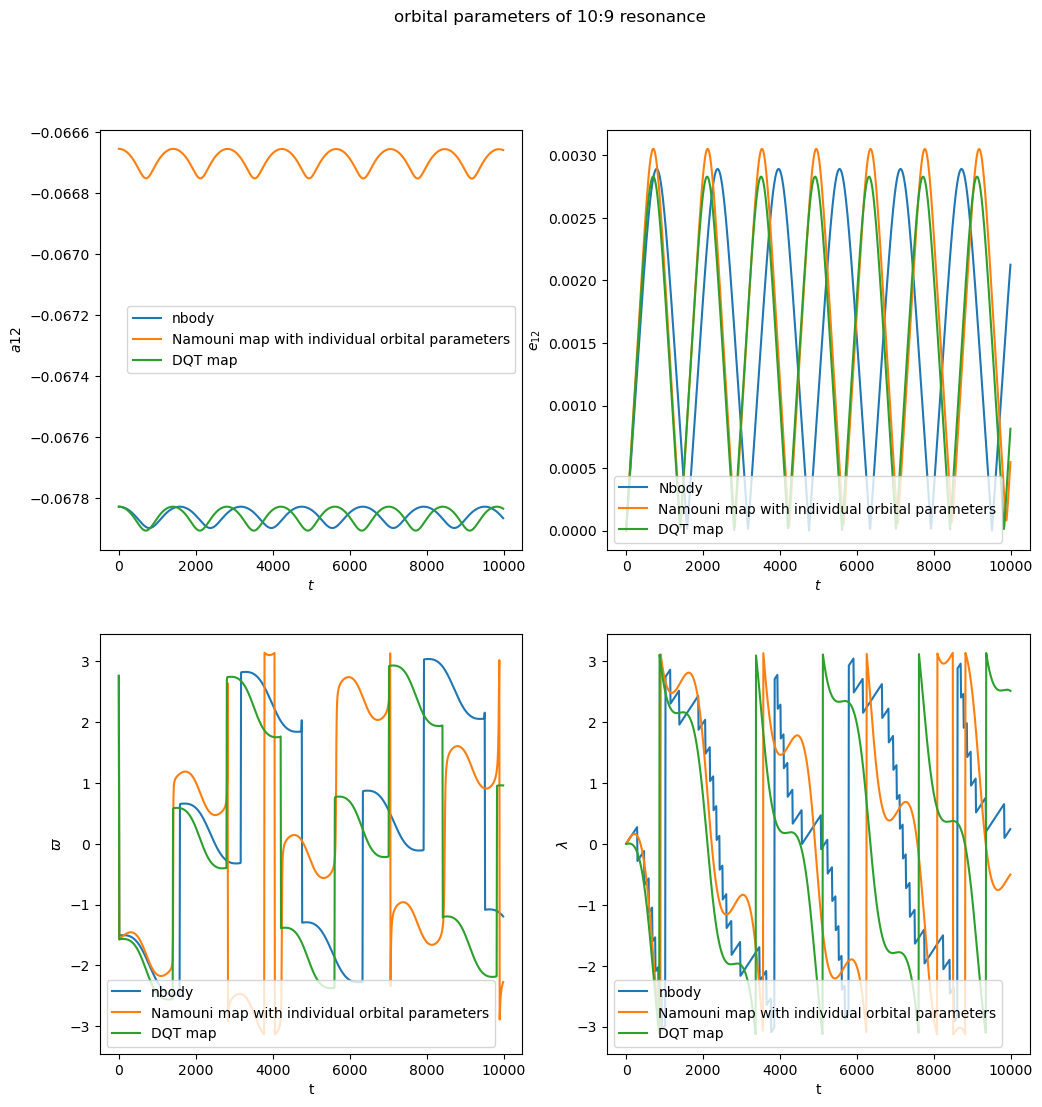

In [35]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize=(12,12))
fig.suptitle(f"orbital parameters of {j}:{j-k} resonance")
ax1.set_ylabel(r'$a12$')
ax1.set_xlabel(r'$t$')
ax1.plot(tbetweens,an,label="nbody")
if ind == 1:
    #ax1.plot(tbetweens, np.sqrt(8/3*Ks0[:-1])*epsilon, label='Namouni map (original, not optimized)')
#    ax1.plot(tbetweens, np.sqrt(8/3*Ks)*epsilon, label='Namouni map (original, optimized)')
    ax1.plot(tbetweens,(a2_s-a1_s)/a1_s, label='Namouni map with individual orbital parameters')
    #ax1.plot(t,np.sqrt(8/3*soltconj[:,2])*epsilon,label='DEs from Namouni map')
    #ax1.plot(tbetweens,-np.sqrt(8/3*Ksn)*epsilon, label="Namouni map (exact lambda update)")
else:
    #ax1.plot(tbetweens, -np.sqrt(8/3*Ks0[:-1])*epsilon, label='Namouni map (original, not optimized)')
#    ax1.plot(tbetweens, -np.sqrt(8/3*Ks)*epsilon, label='Namouni map (original, optimized)')
    ax1.plot(tbetweens,(a1_s-a2_s)/a2_s, label='Namouni map with individual orbital parameters')
    #ax1.plot(t,-np.sqrt(8/3*soltconj[:,2])*epsilon,label='DEs from Namouni map')
    #ax1.plot(tbetweens,-np.sqrt(8/3*Ksn)*epsilon, label="Namouni map (exact lambda update)")

ax1.plot(tbetweens,eps_d, label="DQT map")
ax1.legend()

ax2.set_xlabel('$t$')
ax2.set_ylabel('$e_{12}$')
ax2.plot(tbetweens, e12n, label='Nbody') # plot e12
#ax2.plot(tbetweens,np.sqrt(2*Is0[:-1])*epsilon, label='Namouni map (original, not optimized)')
#ax2.plot(tbetweens,np.sqrt(2*Is)*epsilon, label='Namouni map (original, optimized)') 
#ax2.plot(t, np.sqrt(soltconj[:,0]**2+soltconj[:,1]**2)*epsilon,label = 'DEs from Namouni map')
ax2.plot(tbetweens,np.abs(e2_s-e1_s),label='Namouni map with individual orbital parameters') 
ax2.plot(tbetweens,e12_d,label='DQT map') 
#ax2.plot(tbetweens,np.sqrt(2*Isn)*epsilon, label='Namouni map (exact lambda update)') 
ax2.legend()

ax3.set_ylabel(r'$\varpi$')
ax3.set_xlabel("t")
if ind==1:
    ax3.plot(tbetweens,pomega2_conj,label="nbody")    
else:
    ax3.plot(tbetweens,pomega1_conj,label="nbody")
#ax3.plot(tbetweens, phis0[:-1], label='Namouni map (original, not optimized)')
#ax3.plot(tbetweens, phis, label='Namouni map (original, optimized)')
#ax3.plot(t,pomega_eq,label='DEs from Namouni map')
ax3.plot(tbetweens, pomega_s, label='Namouni map with individual orbital parameters')
ax3.plot(tbetweens, phi_d, label="DQT map")
#ax3.plot(tbetweens, phisn, label='Namouni map (exact lambda update)')
ax3.legend()

ax4.set_ylabel(r'$\lambda$')
ax4.set_xlabel("t")
ax4.plot(tconjs,wrap_angles(l2[conj_idx]),label="nbody")
#ax4.plot(tbetweens, wrap_angles(lambdas0[:-1]), label='Namouni map (original, not optimized)')
#ax4.plot(tbetweens, wrap_angles(lambdas), label='Namouni map (original, optimized)')
#ax4.plot(t,wrap_angles(soltconj[:,3]),label='DEs from Namouni map')
ax4.plot(tbetweens, wrap_angles(lambda_s), label='Namouni map with individual orbital parameters')
ax4.plot(tbetweens, wrap_angles(lambda_d), label="DQT map")
#ax4.plot(tbetweens, wrap_angles(lambdasn), label='Namouni map (exact lambda update)')
ax4.legend()

plt.savefig("plotall.png")

Unfortunately, there is an offset that occurs to the semimajor axis if we use the initial $K$ that minimizes the root-mean-square error of $\lambda$, but without optimization, nothing from the Namouni mapping matches the simulation and DQT mapping.

In some cases, the parameters from the differential equations match with the simulation for only a few cycles then diverge due to the accumulating error, and the conserved quantity does not turn out to be conserved. Perhaps a better integrator can improve the accuracy.

The models that match the simulation (DQT, Namouni with exact lambda update, and original Namouni with optimization (both relative and individual parameters input) with an exception of the semimajor axis) will have a slight lateral shift over time (one factor would be the rounding error). However, the amplitudes from these models should approximately match the simulation.

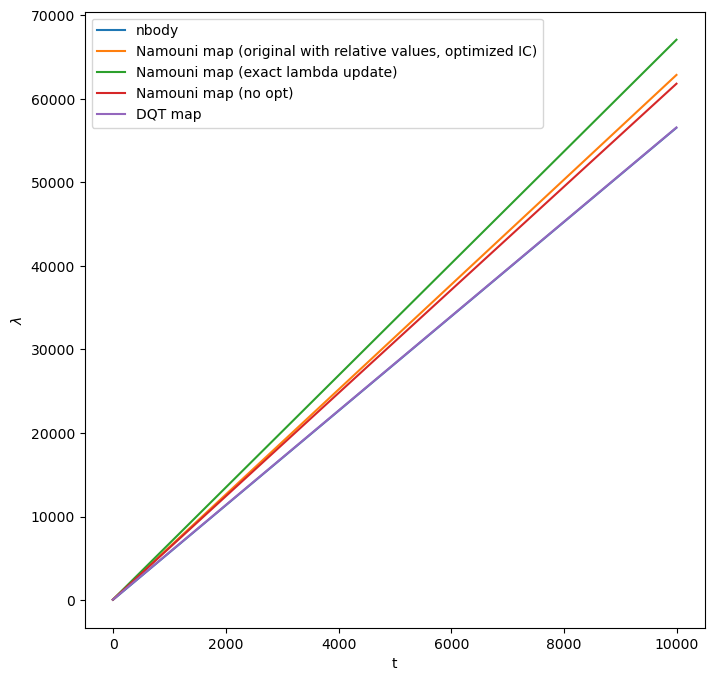

In [36]:

fig, ax4 = plt.subplots(figsize = (8,8))
ax4.set_ylabel(r'$\lambda$')
ax4.set_xlabel("t")
ax4.plot(tconjs,l2[conj_idx],label="nbody")
ax4.plot(tbetweens, lambdas, label='Namouni map (original with relative values, optimized IC)')
ax4.plot(tbetweens, lambdasn, label='Namouni map (exact lambda update)')
ax4.plot(tbetweens, lambdas0, label='Namouni map (no opt)')
#ax4.plot(t,wrap_angles(soltconj[:,3]),label='DEs from Namouni map')
#ax4.plot(tbetweens, wrap_angles(lambda_s[:-1]), label='Namouni map with individual orbital parameters')
ax4.plot(tbetweens, lambda_d, label="DQT map")
ax4.legend()
plt.show()

If we plot the unwrapped version of $\lambda$, we can see that the Namouni map with optimized $K$ is really close to Nbody that we cannot see the values from Nbody unless we zoom in, while the DQT map deviates the most from Nbody when compared this way.

What happens is that we optimized the raw value of $\lambda$ without wrapping, which can affect $K$. Part of the reason is that the wrapped value introduces discontinuity when it approaches $\pm \pi$ as it has to stay within the range.

We can also print out the root-mean-square error of $\lambda$ from different methods and check which one is the largest:

In [37]:
#unwrapped version
lambdarms_exact = np.sqrt(np.mean((lambdasn[:-1] - lambdan)**2))
lambdarms_noopt = np.sqrt(np.mean((lambdas0[:-1]- lambdan)**2))
lambdarms_opt = np.sqrt(np.mean((lambdas[:-1] - lambdan)**2))

print("Namouni original no optimization: ", lambdarms_noopt)
print("Namouni original with optimization: ", lambdarms_opt)
print("Namouni with exact lambda update: ", lambdarms_exact)

Namouni original no optimization:  606.1532950092023
Namouni original with optimization:  0.9892948347407896
Namouni with exact lambda update:  2431.110204954024


Obviously, the optimized $K$ gives the smallest root-mean-square error. The mapping that updates $\lambda$ in the exact way, however, gives the largest root-mean-square error.

In [38]:
#wrapped version
lambdarms_exact = np.sqrt(np.mean((wrap_angles(lambdasn[:-1]) - wrap_angles(lambdan))**2))
lambdarms_noopt = np.sqrt(np.mean((wrap_angles(lambdas0[:-1]) - wrap_angles(lambdan))**2))
lambdarms_opt = np.sqrt(np.mean((wrap_angles(lambdas[:-1]) - wrap_angles(lambdan))**2))

print("Namouni original no optimization: ", lambdarms_noopt)
print("Namouni original with optimization: ", lambdarms_opt)
print("Namouni with exact lambda update: ", lambdarms_exact)

Namouni original no optimization:  2.5001968927857767
Namouni original with optimization:  2.0453824141793455
Namouni with exact lambda update:  2.491241672724335


This is more surprising. The mapping that updates $\lambda$ in the exact way gives the root-mean-square error that is between with and without optimization when $\lambda$ is wrapped. It can also be the smallest in some other conditions (different period ratios etc.).

The cells below try to evaluate the fractional kick of mean motion that can be approximated as the Fourier expansion in terms of $\theta=\lambda_{\text{conj}}-\varpi$:
$$
\frac{\delta n}{n}=2\pi\frac{\mu}{e_c^2}\sum_{m=1}^\infty mA_m^2 \tilde{e}^m\sin(m\theta)
$$

This is an important step because Lizzy (and we will) use this to write the pendulum model of the conjunction angle $\theta$:

$$
\ddot{\theta}=\frac{n^2}{2\pi}\frac{\delta n}{n}(\theta)
$$

which in turn gives the two-body resonant angle from the relationship $\phi=k\theta$. (They are equal when $k=1$.) We need two $\phi$s, one from the inner pair and one from the outer pair, to evaluate the three-body resonant angle $\phi_{\text{3BR}}=\phi_{23}-\phi_{12}$ where the index $23$ indicates the pair formed by the test particle (2) and outer planet (3) and $12$ indicates pair formed by the test particle (2) and inner planet (1).

In this notebook, we implement this series expansion up to the second term (you can choose) because we consider the problem in the low eccentricity limit $\tilde{e}\ll 1$.

In [39]:
A1 = 0.845
A2 = 0.754
#fourier expansion of kick
#first term only
def dnn(theta, mutot, ecross, etilde):
    return (2*np.pi*mutot/ecross**2)*(A1**2)*etilde*np.sin(theta)

#with the second term
def dnn_2o(theta, mutot, ecross, etilde):
    return (2*np.pi*mutot/ecross**2)*((A1**2)*etilde*np.sin(theta) + 2*(A2**2)*etilde**2*np.sin(2*theta))

#take the mean motion of the test particle
if ind == 1:
    ntest_conj = n2_arr[conj_idx]
    ntest_btwn = n2_arr[btwn_conj_idx]
else:
    ntest_conj = n1_arr[conj_idx]
    ntest_btwn = n1_arr[btwn_conj_idx]

# fig8, ax8 = plt.subplots(figsize=(8,8))
# ax8.set_ylabel(r'$n$')
# ax8.set_xlabel(r'$t$')
# ax8.plot(times, n2_arr)

We calculate $\frac{\delta n}{n}$ directly from Nbody's data by finding the difference of the mean motion after and before each conjunction over the value before conjunction. We find it useful to use the values between two conjunctions where things do not jump ridiculously.

In [40]:
deltan = np.diff(ntest_btwn)
dnn_data = deltan/ntest_btwn[:-1]
#print(deltan)
nmap = np.diff(lambdas[:-1])/dtconj
deltanmap = np.diff(nmap)
#print(nmap)

dnn_map = deltanmap/nmap[:-1]

thetas = wrap_angles(lambdas)-phis
dnn_model = dnn(thetas, mutot, ecross, np.sqrt(2*Is)*epsilon/ecross)

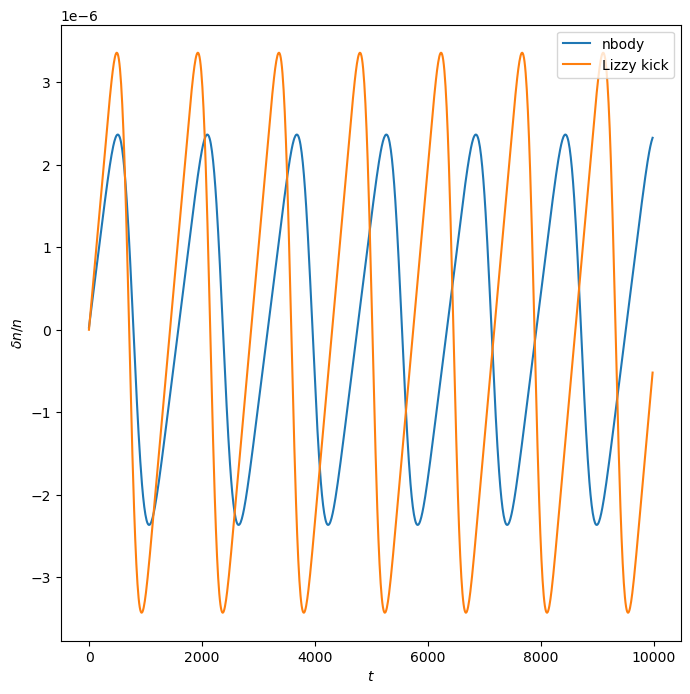

In [41]:
fig8, ax8 = plt.subplots(figsize=(8,8))
ax8.set_ylabel(r'$\delta n/n$')
ax8.set_xlabel(r'$t$')
ax8.plot(tbetweens[:-1], dnn_data, label='nbody')
ax8.plot(tbetweens[:-1], dnn_model[:-1], label='Lizzy kick')
# ax8.plot(tbetweens[:-3], dnn_map, label="Mapping")
ax8.legend()
#ax8.set_xlim(0,500)
plt.savefig('kickplot.png')

Here, we calculate $\theta$ based on what we have in the first-order Namouni mapping with the optimized initial conditions. We have also found out that the amplitude of the Fourier kick (denoted by Lizzy kick on the plot) will not match Nbody if the normalized eccentricity $\tilde{e}$ is kept constant at initial value. This tells us why it is important to couple the eccentricity update (adapted from the Namouni mapping) with the differential equation of the resonant angle!